# 🎬 Netflix Content Analysis — Exploratory Data Analysis


## 1. Setup & Data Loading

In [ ]:
# Install dependencies if needed
# !pip install pandas matplotlib seaborn wordcloud 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')



# ── Plot style ──────────────────────────────────────────────────────────────
# ── Professional clean style ─────────────────────────────

PRIMARY = '#E50914'   # keep Netflix red as accent
SECOND  = '#4C72B0'   # soft blue
ACCENT  = '#555555'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#DDDDDD',

    'axes.labelcolor':  '#333333',
    'xtick.color':      '#333333',
    'ytick.color':      '#333333',
    'text.color':       '#222222',

    'grid.color':       '#E6E6E6',
    'grid.linestyle':   '-',
    'grid.alpha':       0.6,

    'font.family':      'DejaVu Sans',
    'axes.titleweight': 'bold',
    'axes.titlesize':   14,

    'figure.dpi':       120,
})

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [76]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/netflix_titles.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## 2. Data Overview & Cleaning

In [77]:
# ── Basic info ───────────────────────────────────────────────────────────────
print('=== dtypes ===')
print(df.dtypes)
print('\n=== missing values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

=== dtypes ===
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

=== missing values ===
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [78]:
# ── Cleaning ─────────────────────────────────────────────────────────────────

# Parse date_added
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Fill common nulls
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('NR', inplace=True)

# Duration → numeric
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

print('✅ Cleaning done.')
df[['date_added','year_added','month_added','duration_int']].head(3)

✅ Cleaning done.


,date_added,year_added,month_added,duration_int
0,2021-09-25,2021.0,9.0,90.0
1,2021-09-24,2021.0,9.0,2.0
2,2021-09-24,2021.0,9.0,1.0


## 3. Content Type Distribution

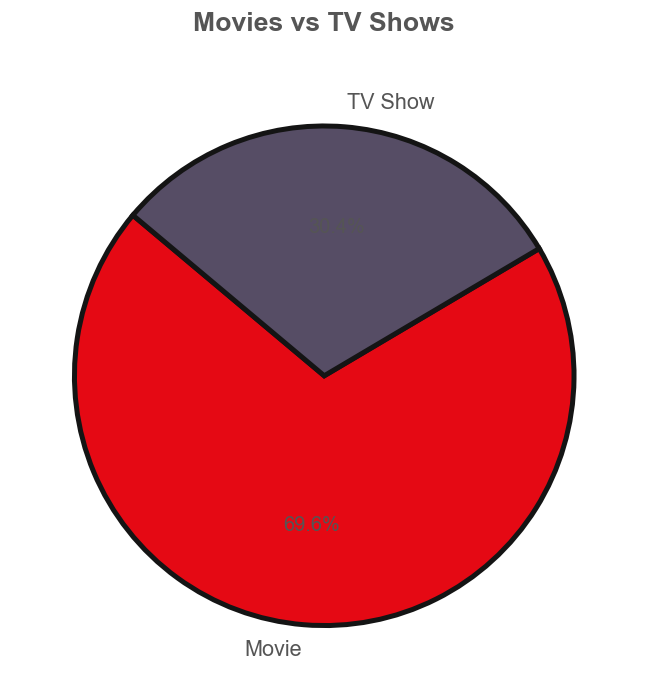

In [79]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED, '#564d65'],
    startangle=140,
    wedgeprops={'edgecolor': NETFLIX_DARK, 'linewidth': 3},
    textprops={'color': ACCENT, 'fontsize': 13}
)
for at in autotexts:
    at.set_fontsize(12)
ax.set_title('Movies vs TV Shows', fontsize=16, pad=20, color=ACCENT, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_type_distribution.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

## 4. Release & Added Trends Over Time

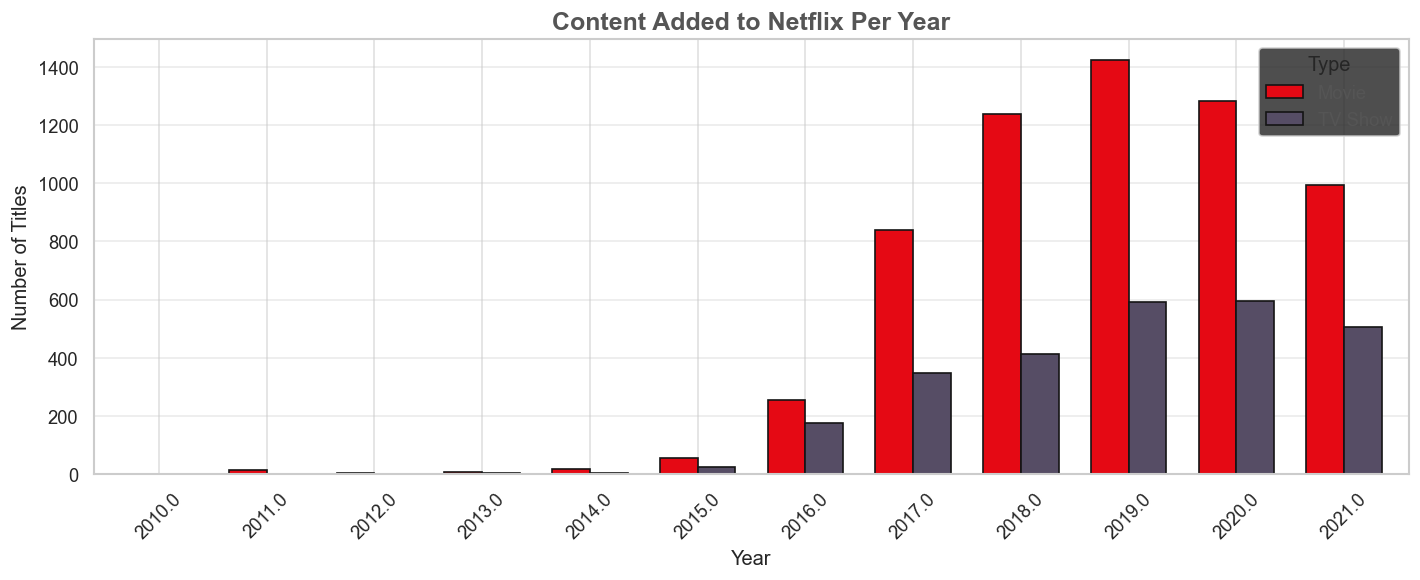

In [80]:
# Content added per year
added_per_year = df[df['year_added'] >= 2010].groupby(['year_added','type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
added_per_year.plot(kind='bar', ax=ax, color=[NETFLIX_RED, '#564d65'], edgecolor=NETFLIX_DARK, width=0.7)
ax.set_title('Content Added to Netflix Per Year', fontsize=15, color=ACCENT, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(title='Type', facecolor='#222', labelcolor=ACCENT)
ax.grid(axis='y', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/plot_added_per_year.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

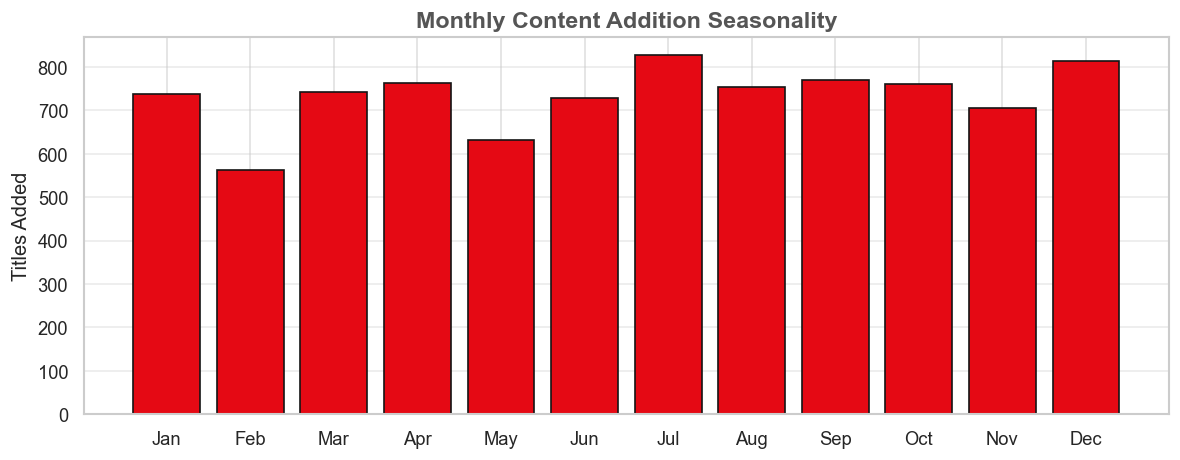

In [81]:
# Monthly seasonality — which months does Netflix add most content?
month_counts = df.groupby('month_added').size()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(month_labels, month_counts.reindex(range(1,13), fill_value=0),
              color=NETFLIX_RED, edgecolor=NETFLIX_DARK)
ax.set_title('Monthly Content Addition Seasonality', fontsize=14, color=ACCENT, fontweight='bold')
ax.set_ylabel('Titles Added')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../plots/plot_monthly_seasonality.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

## 5. Top Countries

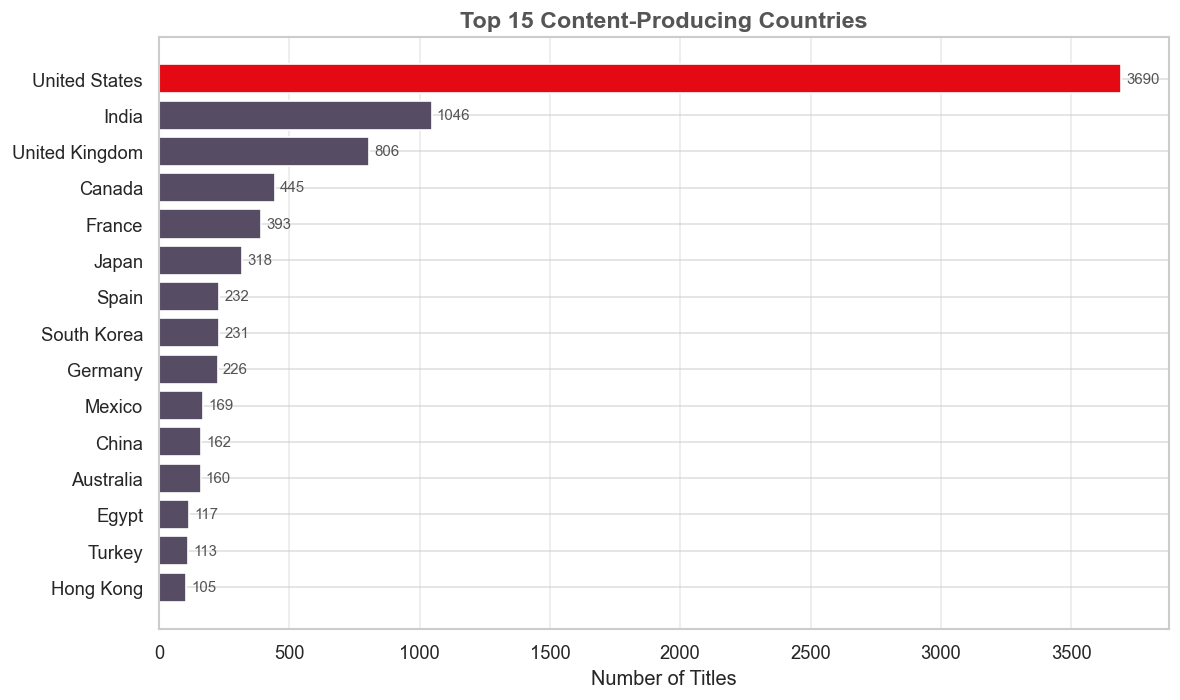

In [82]:
# Explode multi-country entries
country_series = df['country'].str.split(',').explode().str.strip()
top_countries  = country_series[country_series != 'Unknown'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [NETFLIX_RED if i == 0 else '#564d65' for i in range(len(top_countries))]
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Content-Producing Countries', fontsize=14, color=ACCENT, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.grid(axis='x', alpha=0.4)
# Annotate values
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=9, color=ACCENT)
plt.tight_layout()
plt.savefig('../plots/plot_top_countries.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

## 6. Ratings Analysis

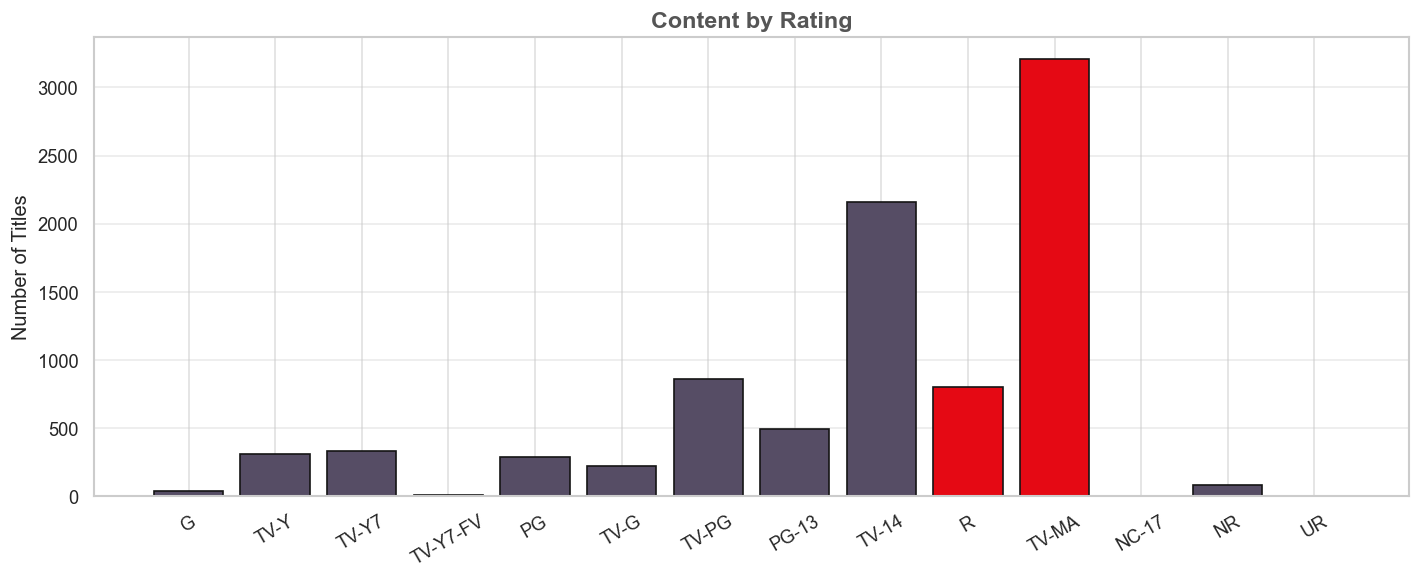

In [83]:
rating_order = ['G','TV-Y','TV-Y7','TV-Y7-FV','PG','TV-G','TV-PG','PG-13','TV-14','R','TV-MA','NC-17','NR','UR']
rating_counts = df['rating'].value_counts().reindex(rating_order).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
palette = [NETFLIX_RED if r in ['TV-MA','R','NC-17'] else '#564d65' for r in rating_counts.index]
ax.bar(rating_counts.index, rating_counts.values, color=palette, edgecolor=NETFLIX_DARK)
ax.set_title('Content by Rating', fontsize=14, color=ACCENT, fontweight='bold')
ax.set_ylabel('Number of Titles')
ax.grid(axis='y', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../plots/plot_ratings.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

## 7. Genre Analysis

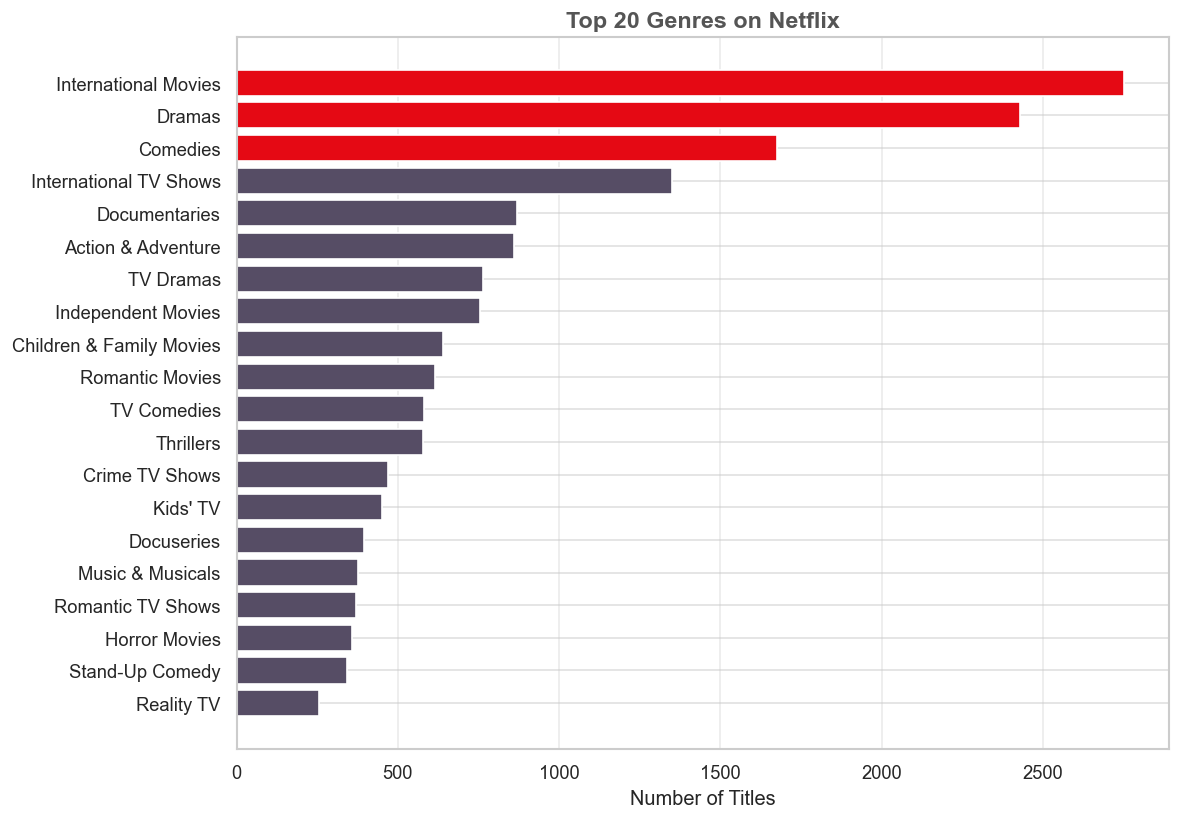

In [84]:
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [NETFLIX_RED if i < 3 else '#564d65' for i in range(len(top_genres))]
ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=colors[::-1])
ax.set_title('Top 20 Genres on Netflix', fontsize=14, color=ACCENT, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('../plots/plot_genres.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

## 8. Movie Duration Analysis

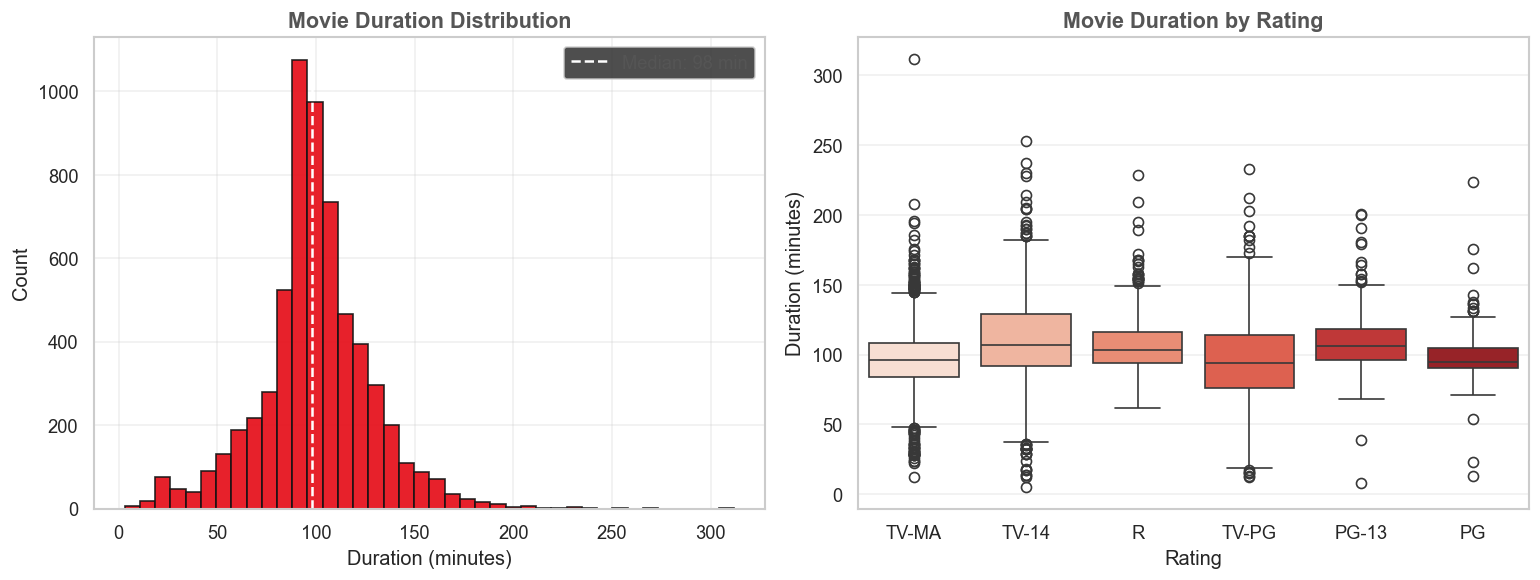

Average movie duration: 99.6 min
Median movie duration:  98 min


In [85]:
movies = df[df['type'] == 'Movie'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(movies['duration_int'].dropna(), bins=40, color=NETFLIX_RED, edgecolor=NETFLIX_DARK, alpha=0.9)
axes[0].axvline(movies['duration_int'].median(), color='white', linestyle='--', label=f'Median: {movies["duration_int"].median():.0f} min')
axes[0].set_title('Movie Duration Distribution', fontsize=13, color=ACCENT, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend(facecolor='#222', labelcolor=ACCENT)
axes[0].grid(alpha=0.3)

# Box plot by rating
top_ratings = movies['rating'].value_counts().head(6).index
subset = movies[movies['rating'].isin(top_ratings)]
sns.boxplot(data=subset, x='rating', y='duration_int', ax=axes[1],
            palette='Reds', order=top_ratings)
axes[1].set_title('Movie Duration by Rating', fontsize=13, color=ACCENT, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Duration (minutes)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/plot_movie_duration.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

print(f"Average movie duration: {movies['duration_int'].mean():.1f} min")
print(f"Median movie duration:  {movies['duration_int'].median():.0f} min")

## 9. TV Show Seasons Analysis

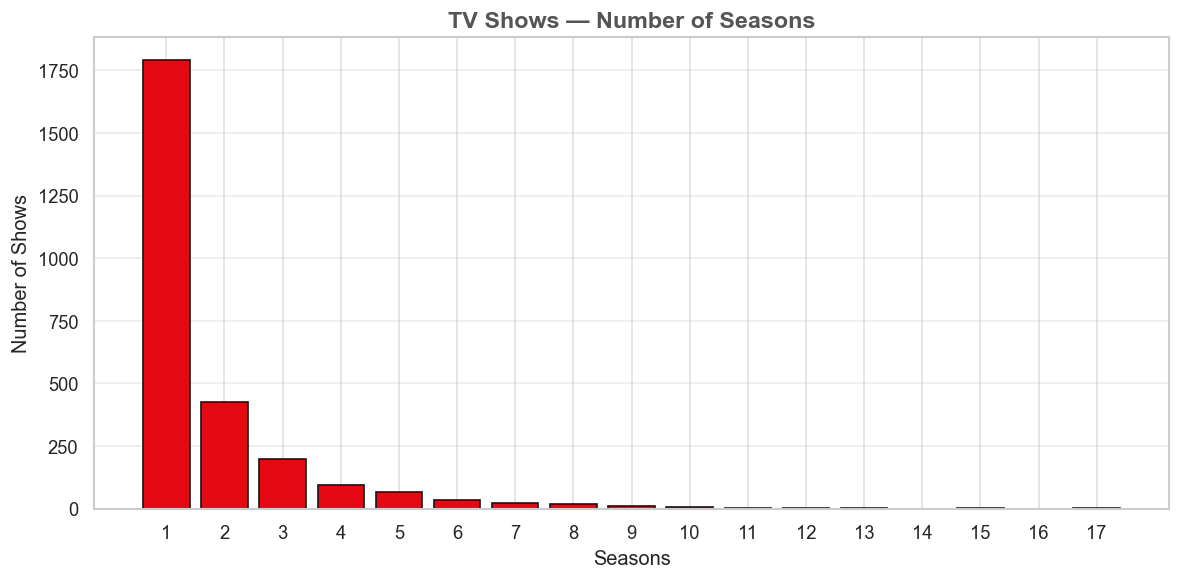

67.0% of TV shows have only 1 season


In [86]:
shows = df[df['type'] == 'TV Show'].copy()
season_counts = shows['duration_int'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(season_counts.index, season_counts.values, color=NETFLIX_RED, edgecolor=NETFLIX_DARK)
ax.set_title('TV Shows — Number of Seasons', fontsize=14, color=ACCENT, fontweight='bold')
ax.set_xlabel('Seasons')
ax.set_ylabel('Number of Shows')
ax.set_xticks(range(1, int(season_counts.index.max())+1))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../plots/plot_seasons.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

one_season_pct = (shows['duration_int'] == 1).mean() * 100
print(f'{one_season_pct:.1f}% of TV shows have only 1 season')

## 10. Top Directors & Cast

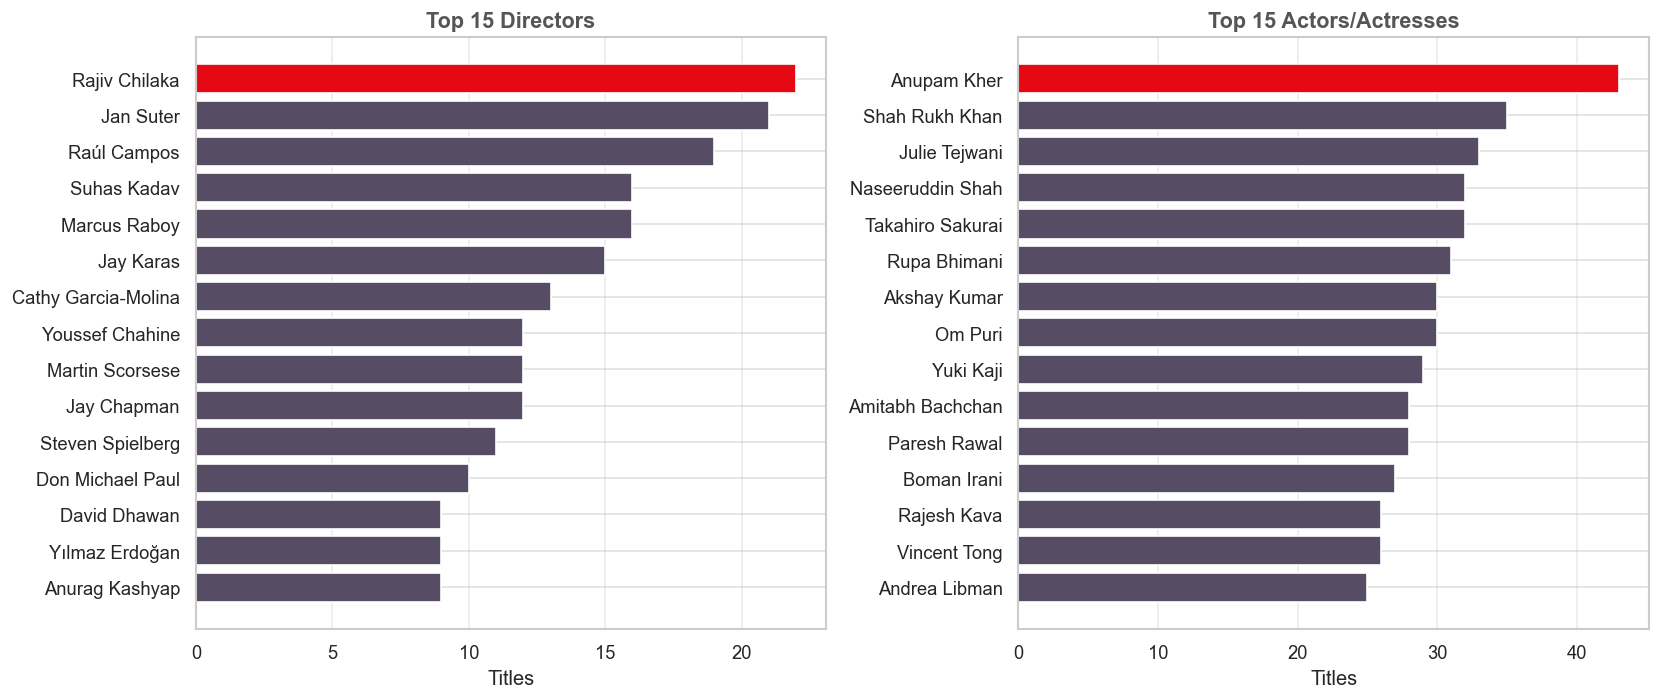

In [87]:
def top_names(series, n=15, exclude='Unknown'):
    return (
        series.str.split(',')
        .explode()
        .str.strip()
        .pipe(lambda s: s[s != exclude])
        .value_counts()
        .head(n)
    )

top_directors = top_names(df['director'])
top_actors    = top_names(df['cast'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in zip(axes,
                           [top_directors, top_actors],
                           ['Top 15 Directors', 'Top 15 Actors/Actresses']):
    colors = [NETFLIX_RED if i == 0 else '#564d65' for i in range(len(data))]
    ax.barh(data.index[::-1], data.values[::-1], color=colors[::-1])
    ax.set_title(title, fontsize=13, color=ACCENT, fontweight='bold')
    ax.set_xlabel('Titles')
    ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('../plots/plot_directors_cast.png', bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()

## 11. Key Takeaways

| Finding | Insight |
|---|---|
| **Movies dominate** | ~70% of the catalogue is movies, but TV shows have been growing faster since 2018 |
| **USA leads production** | United States produces the most content, followed by India and UK |
| **Mature content** | TV-MA and R-rated content is the largest category — Netflix skews adult |
| **Peak addition month** | January and July see the most new content drops |
| **Movie runtime sweet spot** | Most movies are 80–120 minutes; median ~98 min |
| **Most shows don't get renewed** | Over 70% of TV shows have only 1 season on Netflix |
| **Top genre** | International Movies and Dramas are the most common genres |

